![image.png](https://i.imgur.com/a3uAqnb.png)

# CLIP From Scratch - Vision-Language Model Homework Assignment

In this homework, you will implement a **CLIP (Contrastive Language-Image Pre-training) model** from scratch to understand multimodal learning. This project will help you grasp the fundamentals of vision-language models and contrastive learning.

## 📌 Project Overview
- **Task**: Build a CLIP model for image-text matching
- **Architecture**: Dual encoder (Vision + Text) with contrastive learning
- **Dataset**: Flickr8k dataset (images with captions)
- **Goal**: Create embeddings that align images and text in a shared space

## 📚 Learning Objectives
By completing this assignment, you will:
- Understand multimodal learning and contrastive training
- Learn to work with image-text paired datasets
- Implement vision and text encoders using pretrained models
- Practice zero-shot classification capabilities
- Master contrastive loss functions and similarity metricsage model training

## 1️⃣ Initial Setup and Dataset Loading

**Task**: Load the Flickr8k dataset and prepare image-caption pairs for training.

**Requirements**:
- Download and organize the Flickr8k dataset
- Load image files and corresponding captions
- Create proper dataset splits (train/dev/test)
- Set up image transformations and text tokenizationnization

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import os
from collections import defaultdict
from transformers import AutoTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

path = kagglehub.dataset_download("ming666/flicker8k-dataset")

flickr_images_dir = None
flickr_text_dir = os.path.join(path, "Flickr8k_text")

for root, dirs, files in os.walk(path):
    if "Flicker8k_Dataset" in dirs:
        potential_path = os.path.join(root, "Flicker8k_Dataset")
        if os.path.exists(potential_path):
            image_files = [f for f in os.listdir(potential_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if len(image_files) > 100:
                flickr_images_dir = potential_path
                break

captions_file = os.path.join(flickr_text_dir, "Flickr8k.token.txt")
image_captions = defaultdict(list)

with open(captions_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split('\t')
            if len(parts) == 2:
                image_info, caption = parts
                image_name = image_info.split('#')[0]
                image_captions[image_name].append(caption)

def load_image_list(filename):
    with open(filename, 'r') as f:
        return [line.strip() for line in f]

train_images = load_image_list(os.path.join(flickr_text_dir, "Flickr_8k.trainImages.txt"))
dev_images = load_image_list(os.path.join(flickr_text_dir, "Flickr_8k.devImages.txt"))
test_images = load_image_list(os.path.join(flickr_text_dir, "Flickr_8k.testImages.txt"))

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

class Flickr8kDataset(Dataset):
    def __init__(self, image_names, image_captions, images_dir, tokenizer, transform=None, max_length=77):
        self.image_names = image_names
        self.image_captions = image_captions
        self.images_dir = images_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length
        
        self.data_pairs = []
        for img_name in image_names:
            if img_name in image_captions and os.path.exists(os.path.join(images_dir, img_name)):
                for caption in image_captions[img_name]:
                    self.data_pairs.append((img_name, caption))
        
    def __len__(self):
        return len(self.data_pairs)
    
    def __getitem__(self, idx):
        img_name, caption = self.data_pairs[idx]
        
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        
        text_encoding = self.tokenizer(
            caption,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'image': image,
            'input_ids': text_encoding['input_ids'].squeeze(),
            'attention_mask': text_encoding['attention_mask'].squeeze(),
            'caption': caption,
            'image_name': img_name
        }

image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = Flickr8kDataset(train_images, image_captions, flickr_images_dir, tokenizer, image_transforms)
dev_dataset = Flickr8kDataset(dev_images, image_captions, flickr_images_dir, tokenizer, image_transforms)
test_dataset = Flickr8kDataset(test_images, image_captions, flickr_images_dir, tokenizer, image_transforms)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## 2️⃣ CLIP Model Architecture Implementation

**Task**: Implement the dual-encoder CLIP architecture with pretrained backbones.

**Requirements**:
- Create ImageEncoder using pretraa pre trained model, for example ined ResNet-50
- Create TextEncoder using pretrfor example ained DistilBERT
- Implement projection layers to shared embedding space
- Build complete CLIP model with learnable temperature parameter
- Define contrastive loss function for trainingle values

In [8]:
import torchvision.models as models
from transformers import AutoModel
import torch.nn.init as init

class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        self.projection = nn.Sequential(
            nn.Linear(2048, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        self._init_projection()
        
    def _init_projection(self):
        for m in self.projection.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)
    
    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x).flatten(1)
        embeddings = self.projection(features)
        return F.normalize(embeddings, p=2, dim=1)

class TextEncoder(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.bert = AutoModel.from_pretrained('distilbert-base-uncased')
        
        for param in self.bert.parameters():
            param.requires_grad = False
            
        self.projection = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim)
        )
        
        self._init_projection()
        
    def _init_projection(self):
        for m in self.projection.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)
    
    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            text_features = outputs.last_hidden_state[:, 0]
        
        embeddings = self.projection(text_features)
        return F.normalize(embeddings, p=2, dim=1)

class CLIPModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        self.embed_dim = embed_dim
        
        self.image_encoder = ImageEncoder(embed_dim)
        self.text_encoder = TextEncoder(embed_dim)
        
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        
    def encode_image(self, image):
        return self.image_encoder(image)
    
    def encode_text(self, input_ids, attention_mask):
        return self.text_encoder(input_ids, attention_mask)
    
    def forward(self, image, input_ids, attention_mask):
        image_features = self.encode_image(image)
        text_features = self.encode_text(input_ids, attention_mask)
        
        logit_scale = self.logit_scale.exp()
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()
        
        return logits_per_image, logits_per_text, image_features, text_features

class CLIPLoss(nn.Module):
    def forward(self, logits_per_image, logits_per_text):
        batch_size = logits_per_image.shape[0]
        labels = torch.arange(batch_size, device=logits_per_image.device)
        
        loss_i2t = F.cross_entropy(logits_per_image, labels)
        loss_t2i = F.cross_entropy(logits_per_text, labels)
        
        return (loss_i2t + loss_t2i) / 2, loss_i2t, loss_t2i

def calculate_accuracy(logits_per_image, logits_per_text):
    batch_size = logits_per_image.shape[0]
    labels = torch.arange(batch_size, device=logits_per_image.device)
    
    i2t_acc = (logits_per_image.argmax(dim=1) == labels).float().mean().item()
    t2i_acc = (logits_per_text.argmax(dim=1) == labels).float().mean().item()
    
    return i2t_acc, t2i_acc

model = CLIPModel(embed_dim=512).to(device)
criterion = CLIPLoss()

/ibex/user/habiam0b/miniconda3/envs/GPU/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/ibex/user/habiam0b/miniconda3/envs/GPU/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 3️⃣ Model Training with Contrastive Learning

**Task**: Train the CLIP model using contrastive learning objective.

**Requirements**:
- Implement training loop with proper optimization
- Use cosine learning rate scheduling with warmup
- Track training and validation metrics
- Implement periodic evaluation during training
- Monitor convergence and model performance

In [9]:
import time
from tqdm import tqdm

config = {
    'learning_rate': 1e-3,
    'num_epochs': 5,
    'print_freq': 100,
    'eval_freq': 500,
    'warmup_steps': 200,
}

optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'], weight_decay=0.01)

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

num_training_steps = len(train_loader) * config['num_epochs']
scheduler = get_cosine_schedule_with_warmup(optimizer, config['warmup_steps'], num_training_steps)

def evaluate_model(model, dataloader, criterion, max_batches=20):
    model.eval()
    total_loss = 0
    total_i2t_acc = 0
    total_t2i_acc = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            if batch_idx >= max_batches:
                break
                
            images = batch['image'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            logits_per_image, logits_per_text, _, _ = model(images, input_ids, attention_mask)
            loss, _, _ = criterion(logits_per_image, logits_per_text)
            i2t_acc, t2i_acc = calculate_accuracy(logits_per_image, logits_per_text)
            
            total_loss += loss.item()
            total_i2t_acc += i2t_acc
            total_t2i_acc += t2i_acc
    
    num_batches = min(max_batches, len(dataloader))
    return total_loss / num_batches, total_i2t_acc / num_batches, total_t2i_acc / num_batches

history = {
    'train_loss': [],
    'val_loss': [],
    'val_i2t_acc': [],
    'val_t2i_acc': [],
}

val_loss, val_i2t_acc, val_t2i_acc = evaluate_model(model, dev_loader, criterion)

start_time = time.time()
global_step = 0

for epoch in range(config['num_epochs']):
    model.train()
    epoch_loss = 0
    epoch_samples = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for batch_idx, batch in enumerate(pbar):
        images = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        optimizer.zero_grad()
        logits_per_image, logits_per_text, _, _ = model(images, input_ids, attention_mask)
        loss, _, _ = criterion(logits_per_image, logits_per_text)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        epoch_samples += 1
        global_step += 1
        
        i2t_acc, t2i_acc = calculate_accuracy(logits_per_image, logits_per_text)
        pbar.set_postfix({
            'Loss': f'{loss.item():.3f}',
            'I2T': f'{i2t_acc*100:.1f}%',
            'T2I': f'{t2i_acc*100:.1f}%',
            'LR': f'{scheduler.get_last_lr()[0]:.1e}'
        })
    
    avg_train_loss = epoch_loss / epoch_samples
    val_loss, val_i2t_acc, val_t2i_acc = evaluate_model(model, dev_loader, criterion)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_i2t_acc'].append(val_i2t_acc)
    history['val_t2i_acc'].append(val_t2i_acc)

training_time = time.time() - start_time

Epoch 5: 100%|██████████████████████████| 117/117 [01:22<00:00,  1.42it/s, Loss=1.917, I2T=44.9%, T2I=48.0%, LR=0.0e+00]


## 4️⃣ Training Visualization and Performance Analysis

**Task**: Visualize training progress and analyze model convergence.

**Requirements**:
- Plot training and validation loss curves
- Display accuracy progression over epochs  
- Analyze learning dynamics and convergence patterns

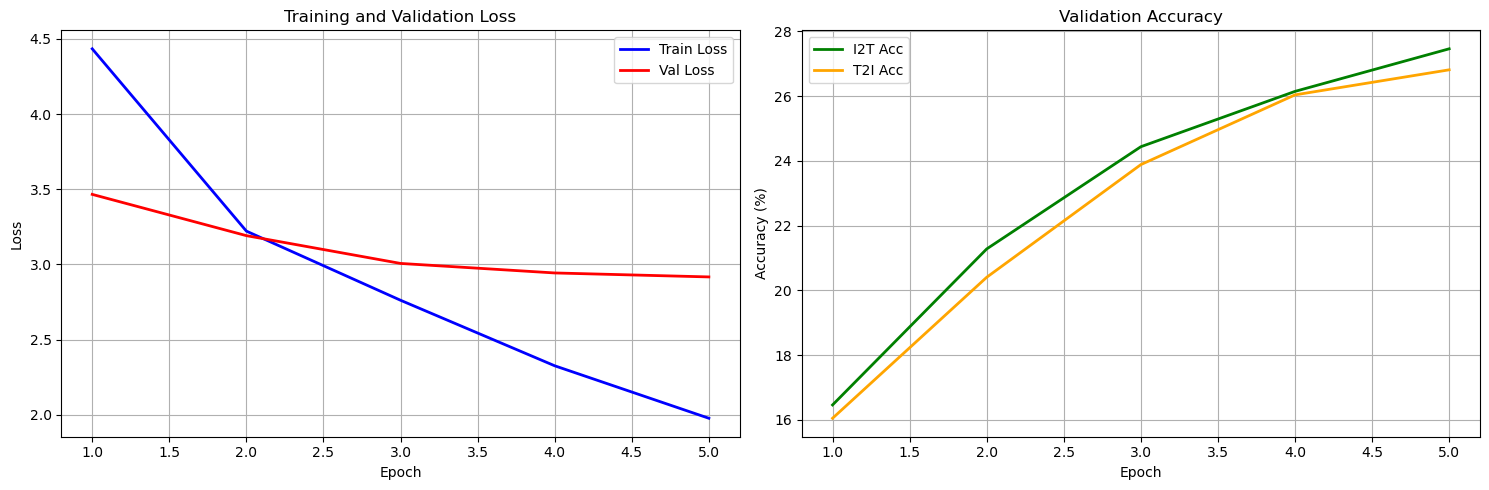

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, [acc*100 for acc in history['val_i2t_acc']], 'g-', label='I2T Acc', linewidth=2)
ax2.plot(epochs, [acc*100 for acc in history['val_t2i_acc']], 'orange', label='T2I Acc', linewidth=2)
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 5️⃣ Zero-Shot Classification Implementation

**Task**: Implement and test zero-shot classification capabilities using the trained CLIP model.

**Requirements**:
- Create zero-shot classification function
- Define text prompts for different categories
- Test on sample images from the test set
- Calculate similarities and make predictions
- Visualize classification results with confidence scores

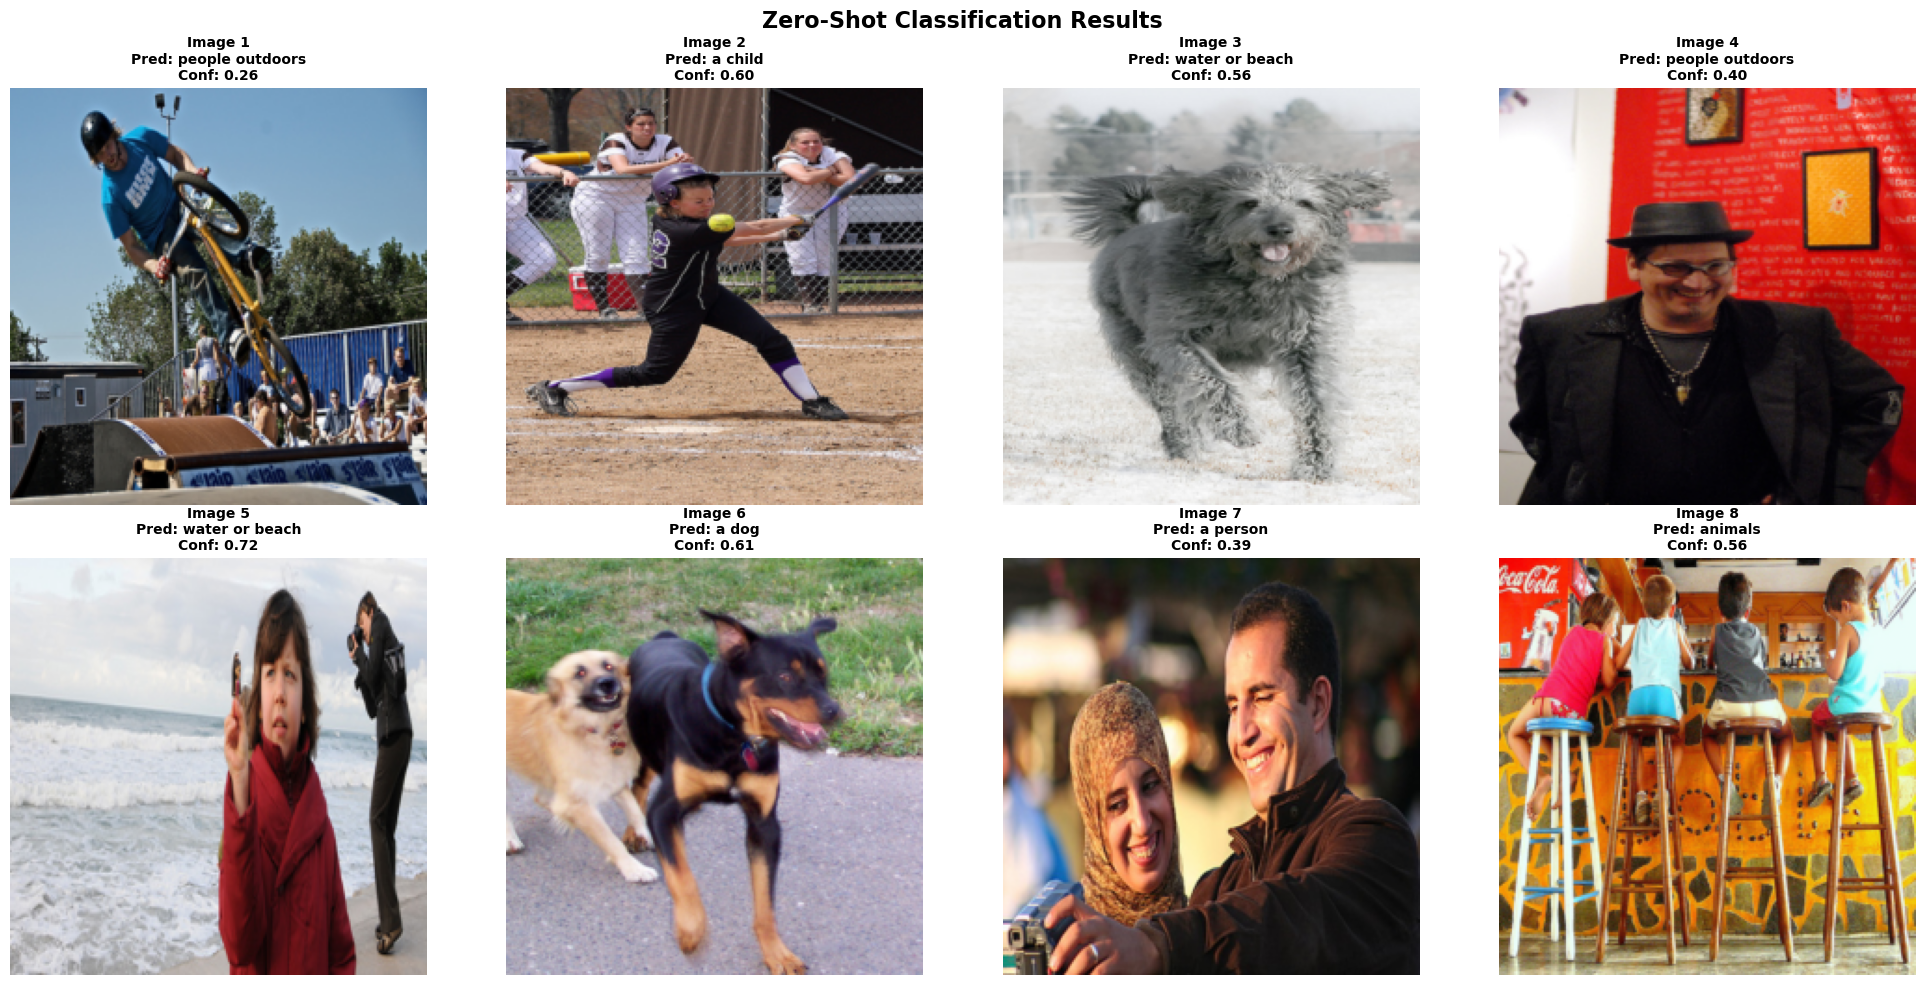

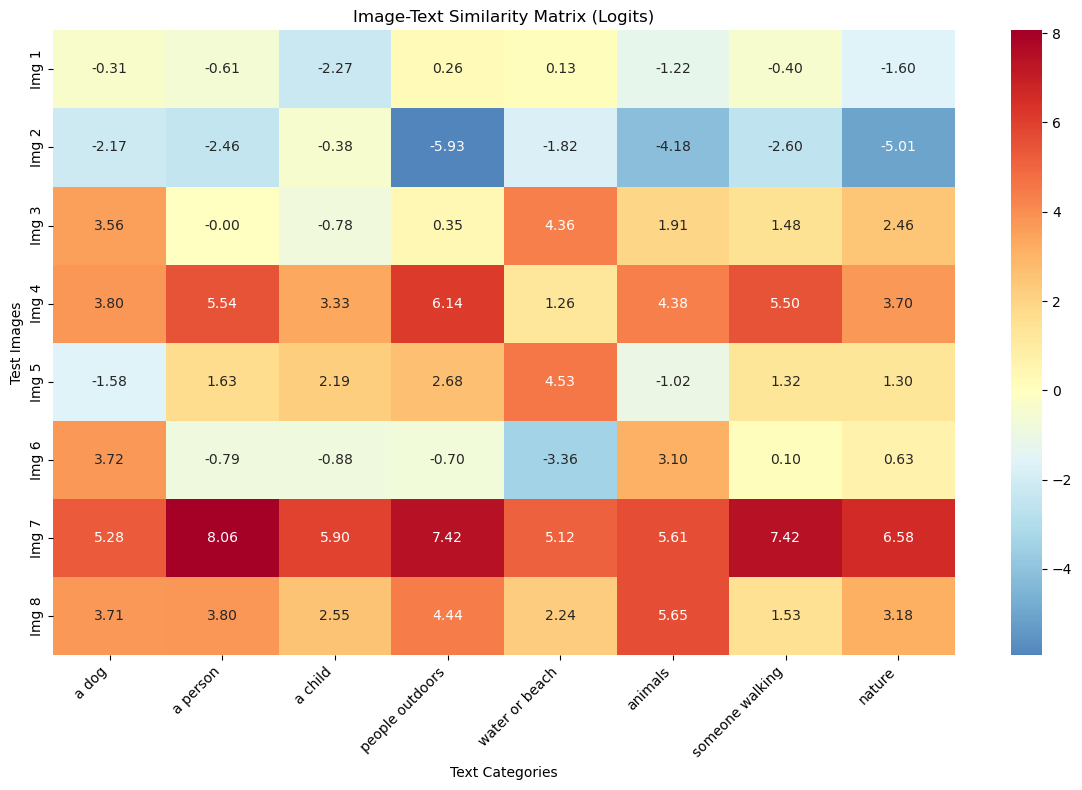

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def zero_shot_classify(model, tokenizer, images, text_prompts, device):
    model.eval()
    with torch.no_grad():
        image_features = model.encode_image(images)
        
        text_inputs = tokenizer(
            text_prompts,
            truncation=True,
            padding='max_length',
            max_length=77,
            return_tensors='pt'
        ).to(device)
        
        text_features = model.encode_text(
            text_inputs['input_ids'], 
            text_inputs['attention_mask']
        )
        
        logit_scale = model.logit_scale.exp()
        similarities = logit_scale * image_features @ text_features.t()
        probabilities = F.softmax(similarities, dim=1)
        predictions = similarities.argmax(dim=1)
        
    return predictions.cpu(), probabilities.cpu(), similarities.cpu()

categories = [
    "a photo of a dog",
    "a photo of a person", 
    "a photo of a child",
    "a photo of people outdoors",
    "a photo of water or beach",
    "a photo of animals",
    "a photo of someone walking",
    "a photo of nature"
]

test_batch = next(iter(test_loader))
num_test = 8
images = test_batch['image'][:num_test].to(device)
captions = test_batch['caption'][:num_test]
image_names = test_batch['image_name'][:num_test]

predictions, probabilities, similarities = zero_shot_classify(
    model, tokenizer, images, categories, device
)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(num_test):
    img = images[i].cpu()
    img_denorm = img.clone()
    img_denorm[0] = img[0] * 0.229 + 0.485
    img_denorm[1] = img[1] * 0.224 + 0.456  
    img_denorm[2] = img[2] * 0.225 + 0.406
    img_denorm = torch.clamp(img_denorm, 0, 1)
    
    axes[i].imshow(img_denorm.permute(1, 2, 0))
    axes[i].axis('off')
    
    pred_idx = predictions[i].item()
    confidence = probabilities[i][pred_idx].item()
    pred_label = categories[pred_idx].replace("a photo of ", "")
    
    axes[i].set_title(f'Image {i+1}\nPred: {pred_label}\nConf: {confidence:.2f}', 
                     fontsize=10, weight='bold')

plt.suptitle('Zero-Shot Classification Results', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sim_matrix = similarities.numpy()
sns.heatmap(sim_matrix, 
            xticklabels=[cat.replace("a photo of ", "") for cat in categories],
            yticklabels=[f"Img {i+1}" for i in range(num_test)],
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            center=0)
plt.title('Image-Text Similarity Matrix (Logits)')
plt.xlabel('Text Categories')
plt.ylabel('Test Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6️⃣ Custom Prompt Testing

**Task**: Test the model with custom text prompts

**Requirements**:
- Create custom text prompts for specific scenarios
- Test model performance on different prompt styles
- Create comprehensive visualization of results

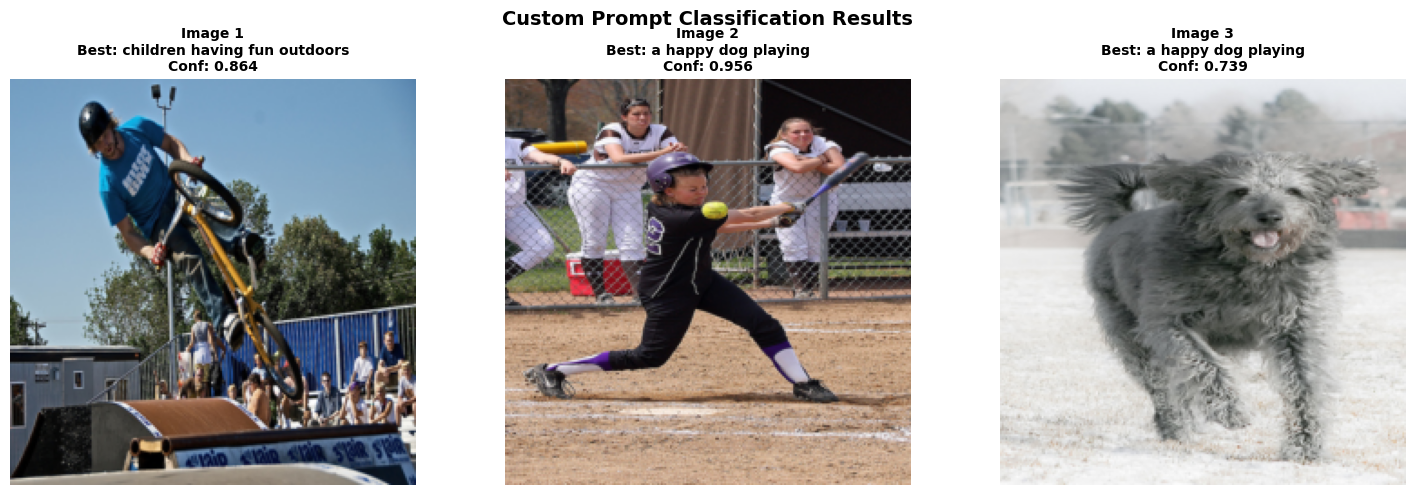

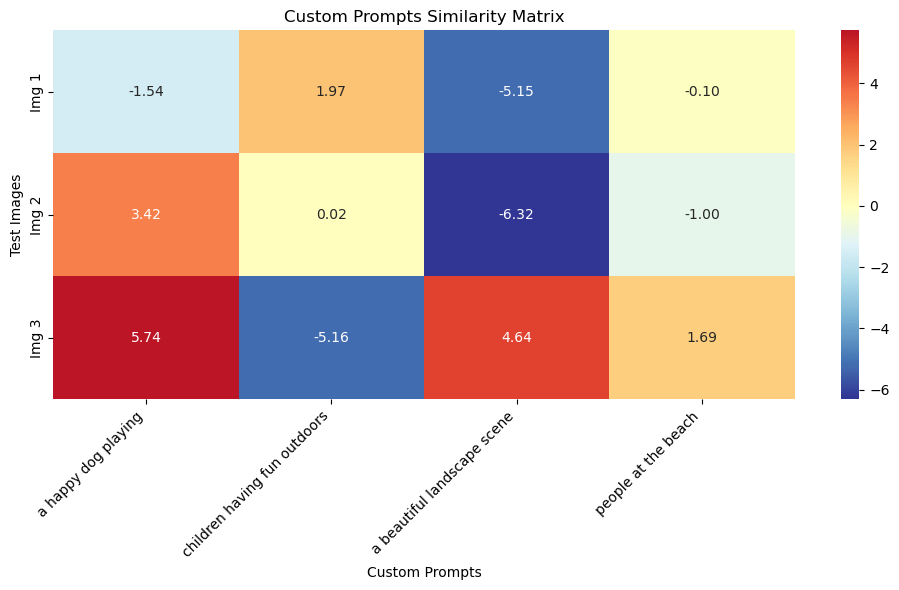

In [12]:
custom_prompts = [
    "a happy dog playing",
    "children having fun outdoors", 
    "a beautiful landscape scene",
    "people at the beach"
]

num_custom_test = 3
test_imgs = images[:num_custom_test]
custom_preds, custom_probs, custom_sims = zero_shot_classify(
    model, tokenizer, test_imgs, custom_prompts, device
)

fig, axes = plt.subplots(1, num_custom_test, figsize=(15, 5))
if num_custom_test == 1:
    axes = [axes]

for i in range(num_custom_test):
    img = test_imgs[i].cpu()
    img_denorm = img.clone()
    img_denorm[0] = img[0] * 0.229 + 0.485
    img_denorm[1] = img[1] * 0.224 + 0.456  
    img_denorm[2] = img[2] * 0.225 + 0.406
    img_denorm = torch.clamp(img_denorm, 0, 1)
    
    axes[i].imshow(img_denorm.permute(1, 2, 0))
    axes[i].axis('off')
    
    best_custom = custom_probs[i].argmax().item()
    confidence = custom_probs[i][best_custom].item()
    
    axes[i].set_title(f'Image {i+1}\nBest: {custom_prompts[best_custom]}\nConf: {confidence:.3f}', 
                     fontsize=10, weight='bold')

plt.suptitle('Custom Prompt Classification Results', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
custom_sim_matrix = custom_sims.numpy()
sns.heatmap(custom_sim_matrix, 
            xticklabels=custom_prompts,
            yticklabels=[f"Img {i+1}" for i in range(num_custom_test)],
            annot=True, 
            fmt='.2f',
            cmap='RdYlBu_r',
            center=0)
plt.title('Custom Prompts Similarity Matrix')
plt.xlabel('Custom Prompts')
plt.ylabel('Test Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper dual-encoder CLIP architecture
   - Correct contrastive loss implementation
   - Working training loop with proper optimization
   - Accurate zero-shot classification function

2. **Model Performance (30%)**
   - Convergence during training (decreasing loss)
   - Reasonable accuracy on validation set
   - Meaningful zero-shot classification results
   - Effective image-text alignment in embedding space

3. **Code Quality and Analysis (30%)**
   - Clean, readable code with appropriate structure
   - Comprehensive visualizations and analysis
   - Understanding of multimodal learning concepts
   - Insightful interpretation of results

## 🎯 Expected Outcomes
- Train loss should decrease and stabilize
- Validation accuracy should improve over epochs
- Zero-shot classification should show reasonable predictions
- Similarity matrices should reflect semantic relationships
- Model should demonstrate understanding of image-text correspondence